In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# for this example we'll improve on the previous setup by adding additional species.
# our disk will consist of a gas with low opacity, and a "dust" fluid that's perfectly coupled to the gas
# and contributes most of the opacity

d2g = 1e-3 # dust-to-gas ratio

# === grid and star ===
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun)
ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=200, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.3, np.pi/2+0.3, Nx=128)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

# === initialization of objects ===
# note that typically when calling a Dust object we should also provide a grain size and density,
# but this only really matters for the calculation of vertical settling, which we ignore here
Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', debug=False, name='basic')
Dust = fld.fluids.Dust(grid=grid, star=star, irradiation='gray', debug=False, name='basic')

# === density and temperature ===
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
# clip the density in the inner regions to mimic the inner rim of the disk
rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.02))

Gas.set_density(np.ones(grid.shape) * rho)
Dust.set_density(np.ones(grid.shape) * rho * d2g)
Gas.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # starting guess from notebook 1
Dust.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # same starting guess

# === opacities and optical depth ===
# low gas opacity
Gas.enroll_kappaR(lambda f: 1e-3 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1e-3 * u.cm**2/u.g)
Gas.enroll_kappaPstar(Gas.get_kappaP)
# optool dust opacity for 0.1 um grains from Ziampras+2025
Dust.enroll_kappaR(lambda f: f.tmp.to_value('K')**1.6 * 0.27 * u.cm**2/u.g)
Dust.enroll_kappaP(lambda f: f.tmp.to_value('K')**1.6 * 0.41 * u.cm**2/u.g)
Dust.enroll_kappaPstar(lambda f: f.star.T.to_value('K')**1.6 * 0.41 * u.cm**2/u.g) # note the stellar T!

# === setup ===
Gas.setup()
Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=True, debug=False, name='disk')

# === boundary conditions ===
bounds, vals = [fld.grid.BOUNDARY_FIXEDVALUE] * 6, [fld.tools.T_to_Er(10*u.K)] * 6
vals[1] = fld.tools.T_to_Er(50*u.K)
Disk.declare_boundaries(bounds, vals)

In [3]:
# run the model
for _ in range(30): Disk.advance(dt=1e10 * u.yr)
# since we're using the previous state as a starting point,
# the more we run, the faster we converge!

RadiativeEnvironment 'disk': Converged in 56 iterations.
RadiativeEnvironment 'disk': Converged in 131 iterations.
RadiativeEnvironment 'disk': Converged in 125 iterations.
RadiativeEnvironment 'disk': Converged in 116 iterations.
RadiativeEnvironment 'disk': Converged in 121 iterations.
RadiativeEnvironment 'disk': Converged in 122 iterations.
RadiativeEnvironment 'disk': Converged in 131 iterations.
RadiativeEnvironment 'disk': Converged in 112 iterations.
RadiativeEnvironment 'disk': Converged in 103 iterations.
RadiativeEnvironment 'disk': Converged in 95 iterations.
RadiativeEnvironment 'disk': Converged in 98 iterations.
RadiativeEnvironment 'disk': Converged in 88 iterations.
RadiativeEnvironment 'disk': Converged in 87 iterations.
RadiativeEnvironment 'disk': Converged in 83 iterations.
RadiativeEnvironment 'disk': Converged in 73 iterations.
RadiativeEnvironment 'disk': Converged in 73 iterations.
RadiativeEnvironment 'disk': Converged in 81 iterations.
RadiativeEnvironment 'd

In [4]:
r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]
mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

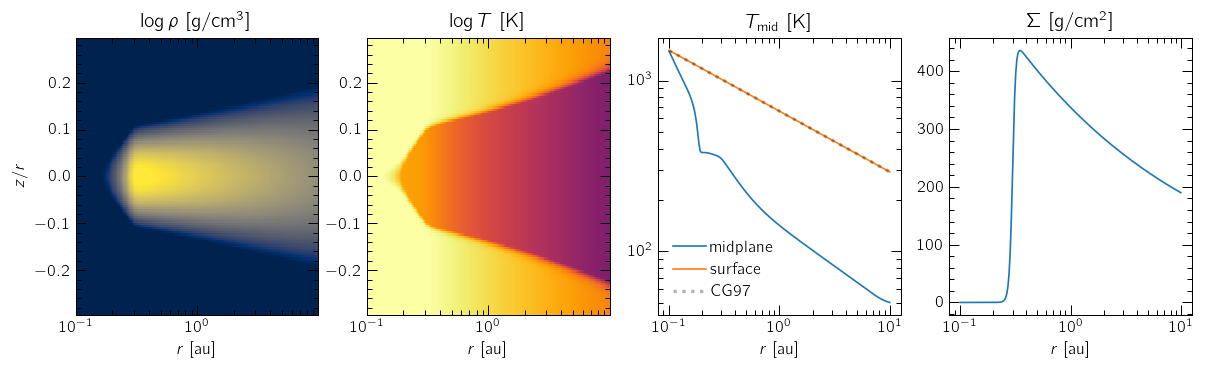

In [5]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = (fmt(Dust.kappaPstar/Dust.kappaP)[0]) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [ ]:
# note the higher temperatures due to the higher opacity from the dust!